In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv(r"C:\Users\gsksd\Downloads\weight-height.csv")

In [10]:
df.shape

(10000, 3)

In [11]:
df.sample(5)

,Gender,Height,Weight
423,Male,70.615744,188.663832
2823,Male,65.768518,171.405226
1538,Male,69.632939,200.562613
8435,Female,65.706580,149.715823
139,Male,68.140590,183.044660


In [13]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Count'>

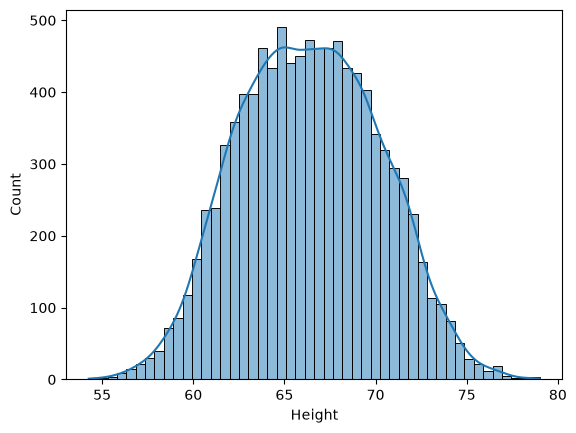

In [15]:
sns.histplot(df['Height'],kde=True)

<Axes: ylabel='Height'>

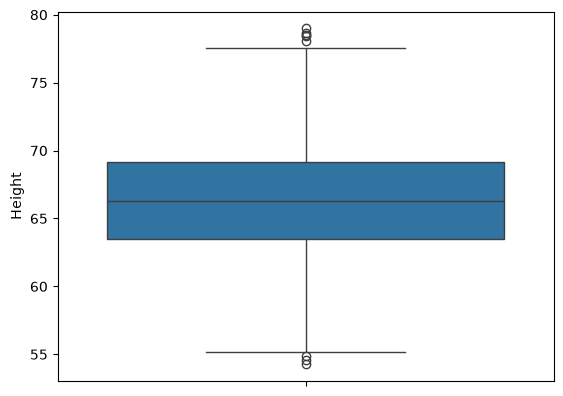

In [16]:
sns.boxplot(df['Height'])

In [17]:
upper_limit = df['Height'].quantile(0.99)
upper_limit

np.float64(74.7857900583366)

In [19]:
lower_limit = df['Height'].quantile(0.01)
lower_limit

np.float64(58.13441158671655)

In [20]:
new_df = df[(df['Height'] <= 74.78) & (df['Height'] >= 58.13)]

In [22]:
new_df.shape

(9799, 3)

In [23]:
new_df.describe()

,Height,Weight
count,9799.000000,9799.000000
mean,66.363507,161.391522
std,3.644267,30.925072
min,58.134496,77.523774
25%,63.577147,136.320936
50%,66.317899,161.201891
75%,69.119859,186.747036
max,74.767447,249.946283


<Axes: xlabel='Height', ylabel='Count'>

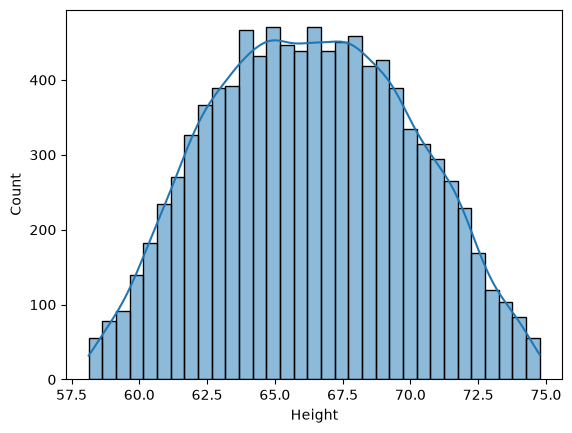

In [25]:
sns.histplot(new_df['Height'],kde=True)

<Axes: ylabel='Height'>

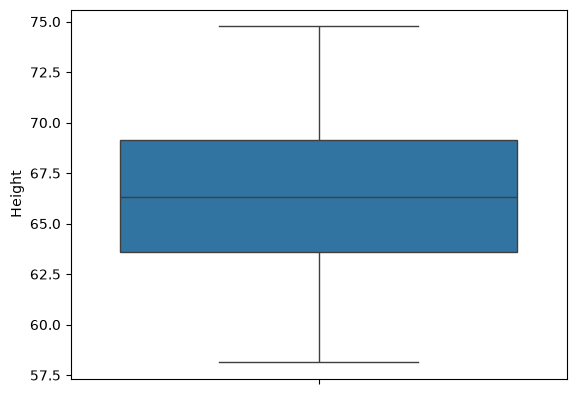

In [27]:
sns.boxplot(new_df['Height'])

## Capping | Winsorization

In [28]:
df['Height'] = np.where(
    df['Height'] >= upper_limit,
        upper_limit,
        np.where(
            df['Height'] <= lower_limit,
        lower_limit,
        df['Height']
                )
)

In [29]:

df.shape

(10000, 3)

In [30]:
df['Height'].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Count'>

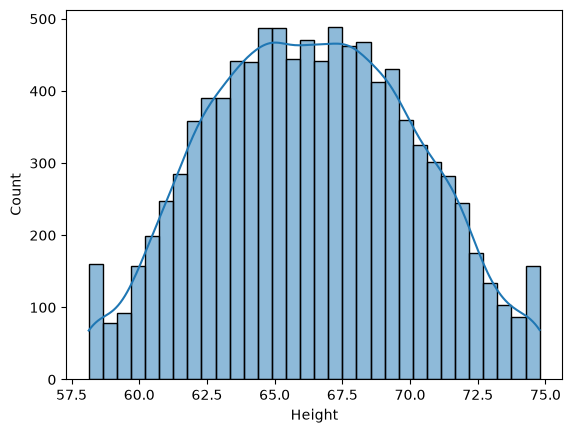

In [32]:

sns.histplot(df['Height'],kde=True)

<Axes: ylabel='Height'>

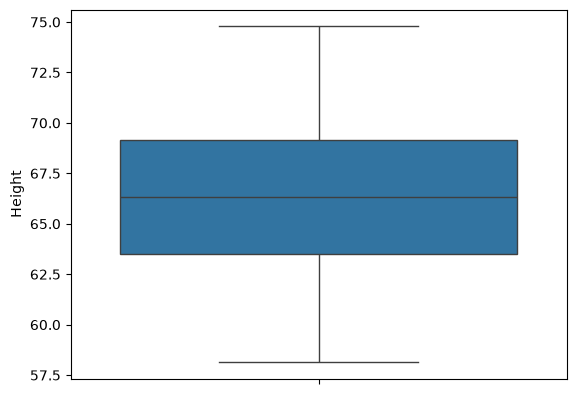

In [33]:
sns.boxplot(df['Height'])